In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [2]:
df = pd.read_csv('genz_social_media_usage_1M.csv')
print(df.shape)

(1000000, 12)


In [3]:
print(df.head())

   age  gender    country  daily_usage_hours primary_platform  \
0   19    Male  Australia           2.658617         Snapchat   
1   16  Female        USA           5.685387          Twitter   
2   25  Female      India           2.782420           TikTok   
3   27    Male      India           3.486598          YouTube   
4   23  Female      India           3.748829           TikTok   

   num_platforms_used        purpose  avg_session_minutes  night_usage  \
0                   4      Education            29.222443            0   
1                   3    Socializing            32.464726            1   
2                   2    Socializing            18.170204            1   
3                   4      Education            22.493804            1   
4                   1  Entertainment            27.358410            1   

   mental_health_score addiction_level  screen_time_before_sleep  
0             6.705830          Medium                 15.779443  
1             6.633111        

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   gender                    1000000 non-null  object 
 2   country                   1000000 non-null  object 
 3   daily_usage_hours         1000000 non-null  float64
 4   primary_platform          1000000 non-null  object 
 5   num_platforms_used        1000000 non-null  int64  
 6   purpose                   1000000 non-null  object 
 7   avg_session_minutes       1000000 non-null  float64
 8   night_usage               1000000 non-null  int64  
 9   mental_health_score       1000000 non-null  float64
 10  addiction_level           1000000 non-null  object 
 11  screen_time_before_sleep  1000000 non-null  float64
dtypes: float64(4), int64(3), object(5)
memory usage: 91.6+ MB
None


In [5]:
print(df.describe())

                  age  daily_usage_hours  num_platforms_used  \
count  1000000.000000     1000000.000000      1000000.000000   
mean        19.994629           3.514998            2.999469   
std          4.322119           1.468771            1.414598   
min         13.000000           0.500000            1.000000   
25%         16.000000           2.493985            2.000000   
50%         20.000000           3.503302            3.000000   
75%         24.000000           4.513016            4.000000   
max         27.000000          10.000000            5.000000   

       avg_session_minutes     night_usage  mental_health_score  \
count       1000000.000000  1000000.000000       1000000.000000   
mean             25.088819        0.599958             7.170671   
std               9.794249        0.489907             1.503885   
min               5.000000        0.000000             1.000000   
25%              18.257267        0.000000             6.147371   
50%              25.0

In [6]:
print(df.duplicated().sum())

0


In [7]:
print(df.describe(include='object'))

         gender  country primary_platform        purpose addiction_level
count   1000000  1000000          1000000        1000000         1000000
unique        3        7                5              5               3
top      Female    India        Instagram  Entertainment          Medium
freq     480113   350321           299927         400052          589843


In [8]:
# Check for type mismatches — common issue after loading CSVs
for col in df.columns:
    if df[col].dtype == 'object':
        # Try to detect if it should be numeric
        try:
            pd.to_numeric(df[col].str.replace(',',''))
            print(f'{col} may be numeric — stored as object!')
        except:
            pass


In [9]:
print(df.isnull().sum())

age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_session_minutes         0
night_usage                 0
mental_health_score         0
addiction_level             0
screen_time_before_sleep    0
dtype: int64


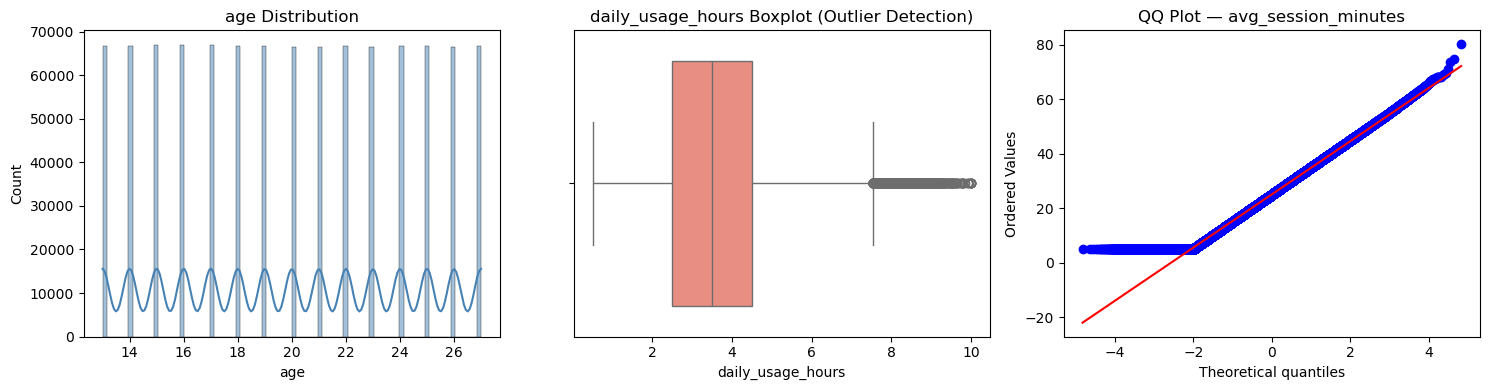

Mean: 19.99
Skewness: 0.002(|skew|>1 = highly skewed)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


sns.histplot(df['age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('age Distribution')


sns.boxplot(x=df['daily_usage_hours'], ax=axes[1], color='salmon')
axes[1].set_title('daily_usage_hours Boxplot (Outlier Detection)')


stats.probplot(df['avg_session_minutes'], dist='norm', plot=axes[2])
axes[2].set_title('QQ Plot — avg_session_minutes')

plt.tight_layout()
plt.show()


print(f'Mean: {df["age"].mean():.2f}')
print(f'Skewness: {df["age"].skew():.3f}(|skew|>1 = highly skewed)')

gender
Female    480113
Male      479576
Other      40311
Name: count, dtype: int64
gender
Female    0.480113
Male      0.479576
Other     0.040311
Name: proportion, dtype: float64


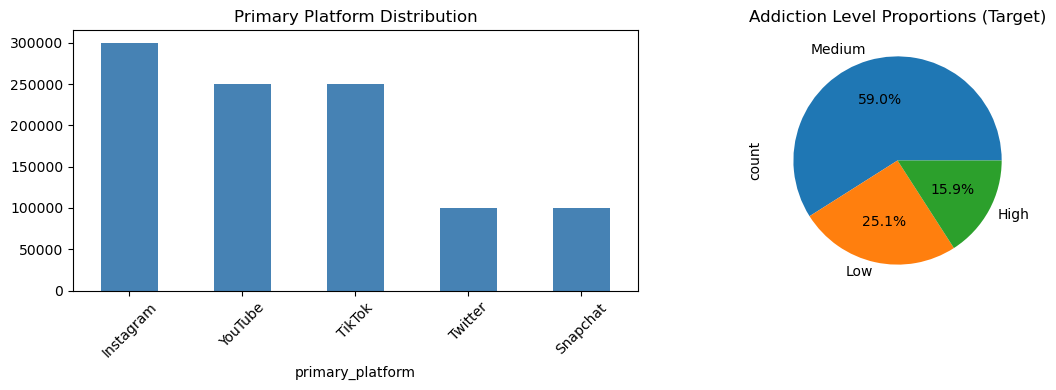

In [11]:
# Value counts — how many of each category?
print(df['gender'].value_counts())
print(df['gender'].value_counts(normalize=True))  # As percentages

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — use primary_platform (most interesting categorical column)
df['primary_platform'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Primary Platform Distribution')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart — use addiction_level (your TARGET variable)
df['addiction_level'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Addiction Level Proportions (Target)')

plt.tight_layout()
plt.show()

In [12]:
# Constants — edit these if you want to change the target or features
TARGET       = 'addiction_level'
TARGET_ORDER = ['Low', 'Medium', 'High']
NUM_COLS     = ['age', 'daily_usage_hours', 'num_platforms_used',
                'avg_session_minutes', 'mental_health_score',
                'screen_time_before_sleep']
 
# Sample for plots that are slow on 1M rows (pairplot, scatterplot)
df_sample = df.sample(5000, random_state=42)

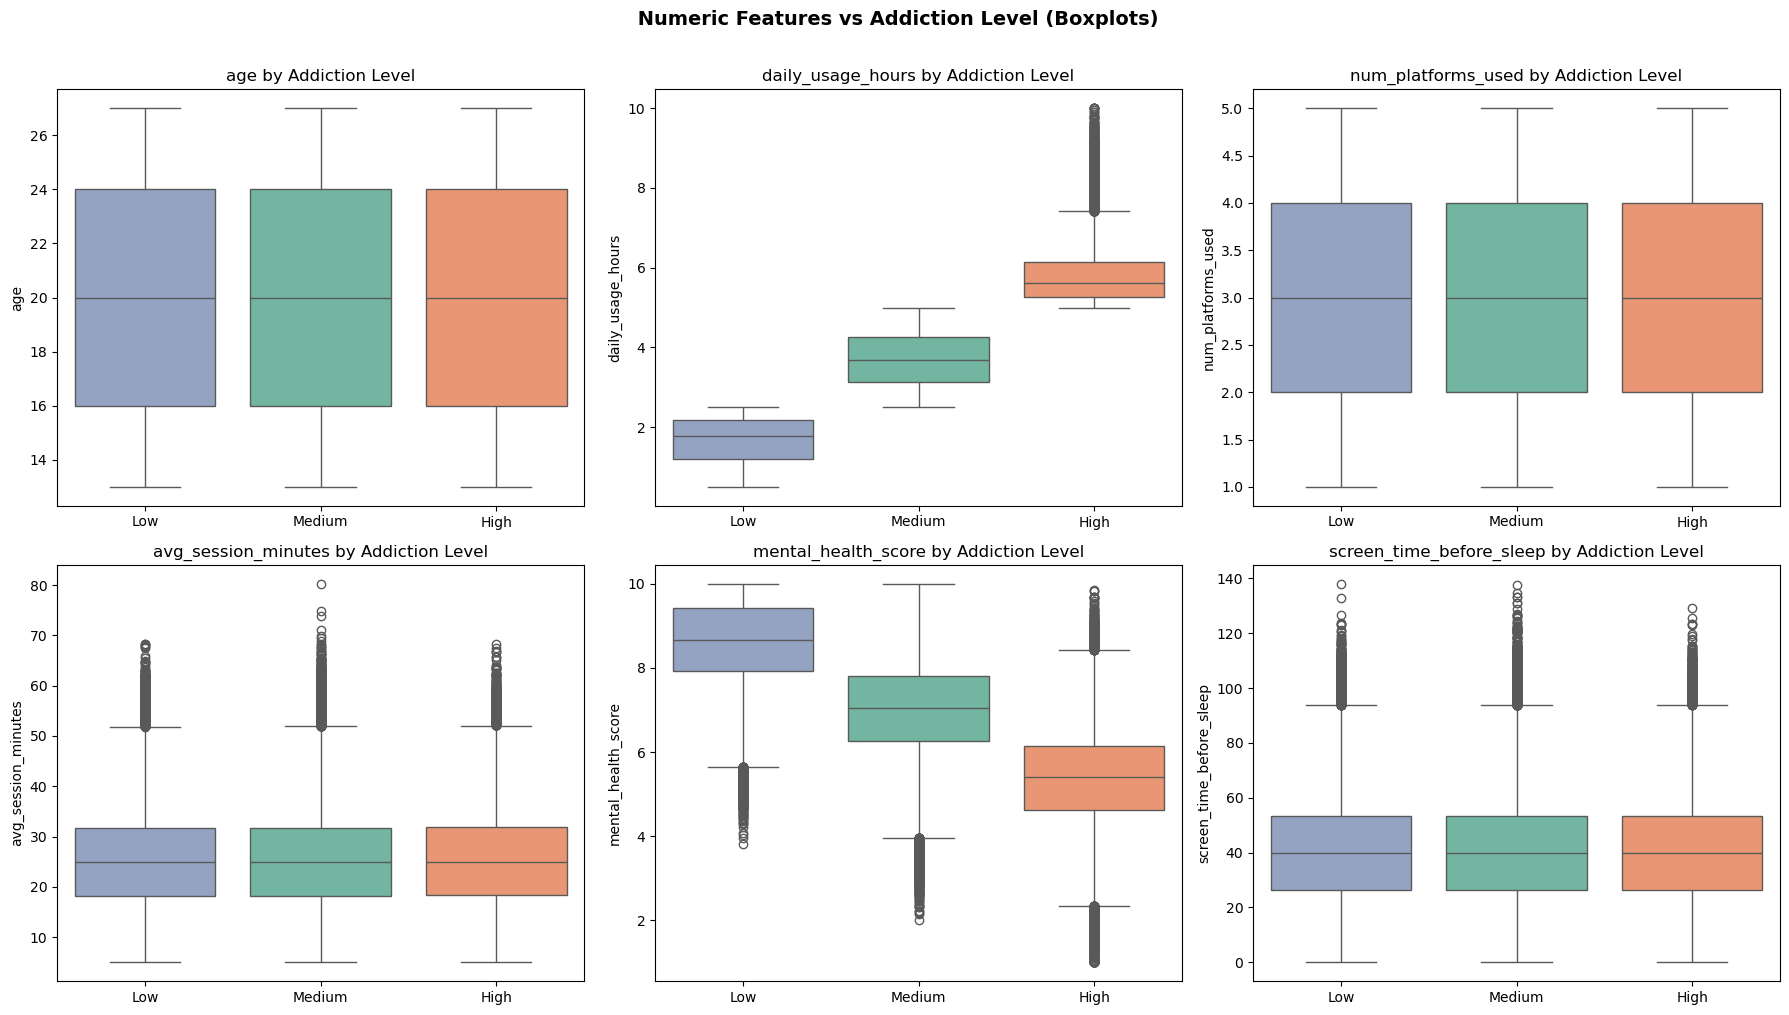

In [13]:
#  Numeric features vs Target (Boxplots) 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(' Numeric Features vs Addiction Level (Boxplots)',
             fontsize=14, fontweight='bold', y=1.01)
 

for ax, col in zip(axes.flatten(), NUM_COLS):
    sns.boxplot(x=TARGET, y=col, data=df,
                order=TARGET_ORDER, palette='Set2',
                hue=TARGET, legend=False,        # ← add these two
                ax=ax)
    ax.set_title(f'{col} by Addiction Level')
    ax.set_xlabel('')
 
plt.tight_layout()
plt.show()

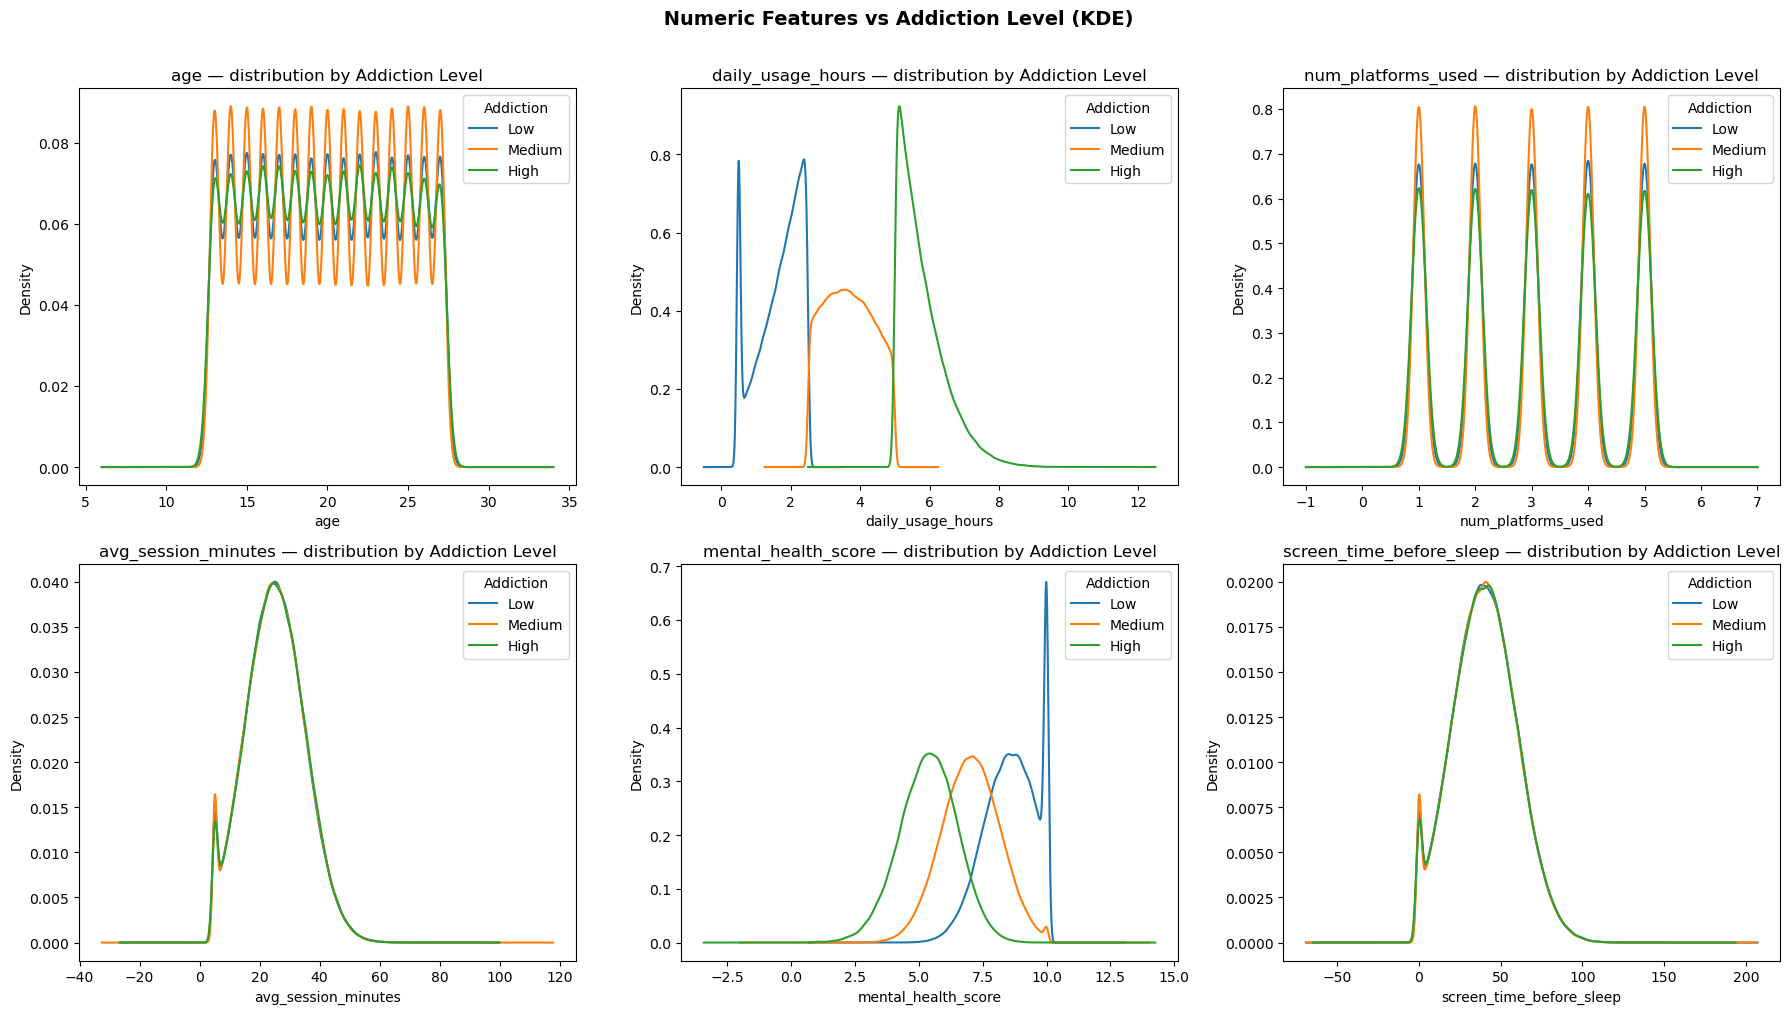

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(' Numeric Features vs Addiction Level (KDE)',
             fontsize=14, fontweight='bold', y=1.01)
 
for ax, col in zip(axes.flatten(), NUM_COLS):
    for level in TARGET_ORDER:
        df[df[TARGET] == level][col].plot(kind='kde', ax=ax, label=level)
    ax.set_title(f'{col} — distribution by Addiction Level')
    ax.legend(title='Addiction')
    ax.set_xlabel(col)
 
plt.tight_layout()
plt.show()

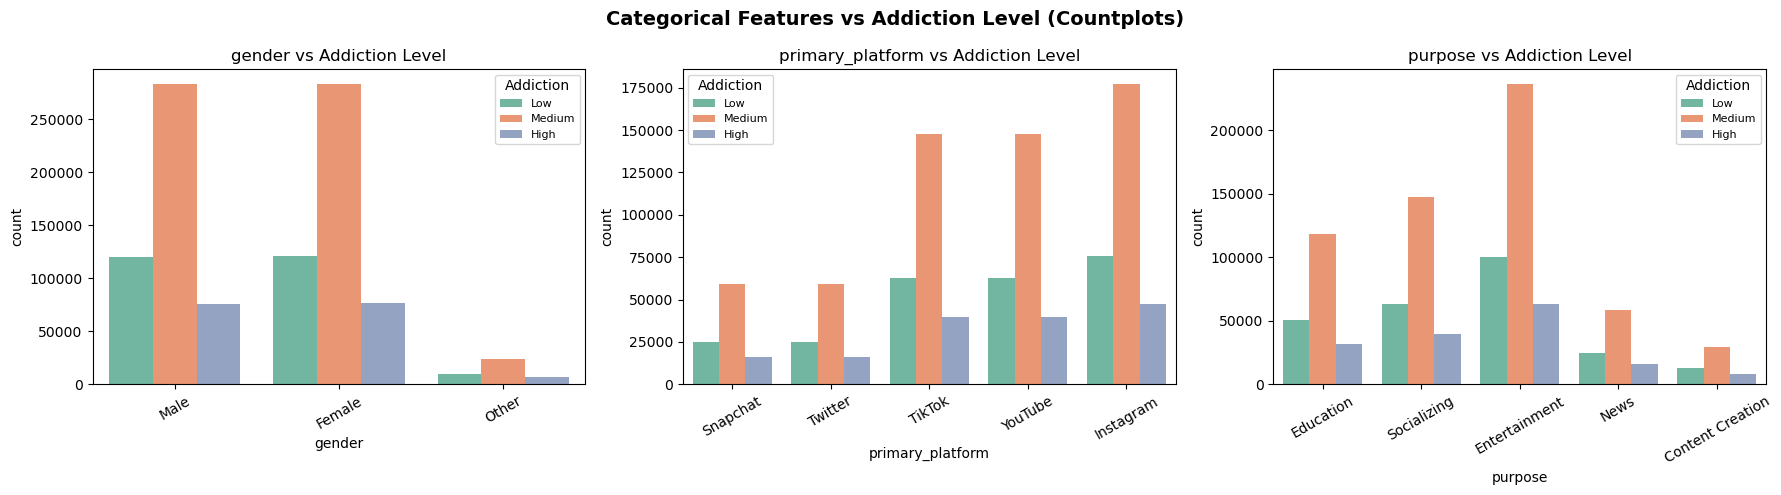

In [15]:
#  Categorical features vs Target (Countplots)
cat_cols = ['gender', 'primary_platform', 'purpose']
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Categorical Features vs Addiction Level (Countplots)',
             fontsize=14, fontweight='bold')
 
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, hue=TARGET, hue_order=TARGET_ORDER,
                  data=df, palette='Set2', ax=ax)
    ax.set_title(f'{col} vs Addiction Level')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Addiction', fontsize=8)
 
plt.tight_layout()
plt.show()

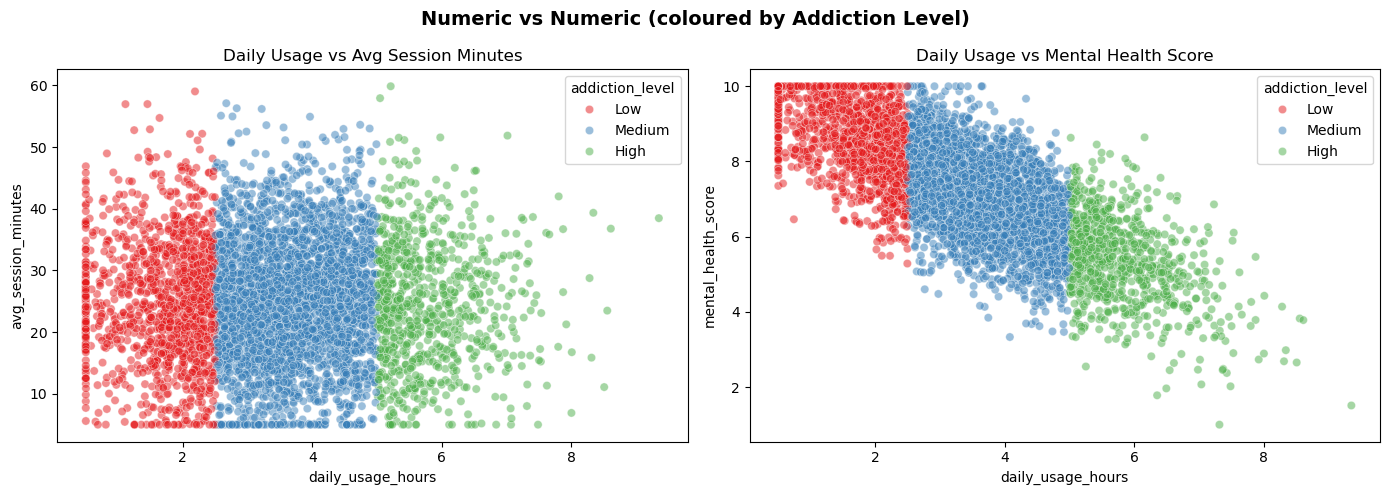

In [16]:
# Numeric vs Numeric — Scatter (coloured by target)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Numeric vs Numeric (coloured by Addiction Level)',
             fontsize=14, fontweight='bold')
 
# daily_usage_hours vs avg_session_minutes
sns.scatterplot(x='daily_usage_hours', y='avg_session_minutes',
                hue=TARGET, hue_order=TARGET_ORDER,
                data=df_sample, alpha=0.5, palette='Set1', ax=axes[0])
axes[0].set_title('Daily Usage vs Avg Session Minutes')
 
# daily_usage_hours vs mental_health_score
sns.scatterplot(x='daily_usage_hours', y='mental_health_score',
                hue=TARGET, hue_order=TARGET_ORDER,
                data=df_sample, alpha=0.5, palette='Set1', ax=axes[1])
axes[1].set_title('Daily Usage vs Mental Health Score')
 
plt.tight_layout()
plt.show()

In [17]:
#  Pearson Correlations — numeric pairs 
print(' Pearson Correlation (numeric pairs)')
pairs = [
    ('daily_usage_hours',  'avg_session_minutes'),
    ('daily_usage_hours',  'mental_health_score'),
    ('daily_usage_hours',  'screen_time_before_sleep'),
    ('mental_health_score','screen_time_before_sleep'),
    ('age',                'daily_usage_hours'),
]
for col1, col2 in pairs:
    r = df[col1].corr(df[col2])
    print(f'  {col1} ↔ {col2}: {r:.3f}')
print()
print('  Interpretation: >0.7 strong positive | <-0.7 strong negative | ~0 no linear relationship')

 Pearson Correlation (numeric pairs)
  daily_usage_hours ↔ avg_session_minutes: 0.001
  daily_usage_hours ↔ mental_health_score: -0.762
  daily_usage_hours ↔ screen_time_before_sleep: 0.000
  mental_health_score ↔ screen_time_before_sleep: -0.000
  age ↔ daily_usage_hours: -0.001

  Interpretation: >0.7 strong positive | <-0.7 strong negative | ~0 no linear relationship


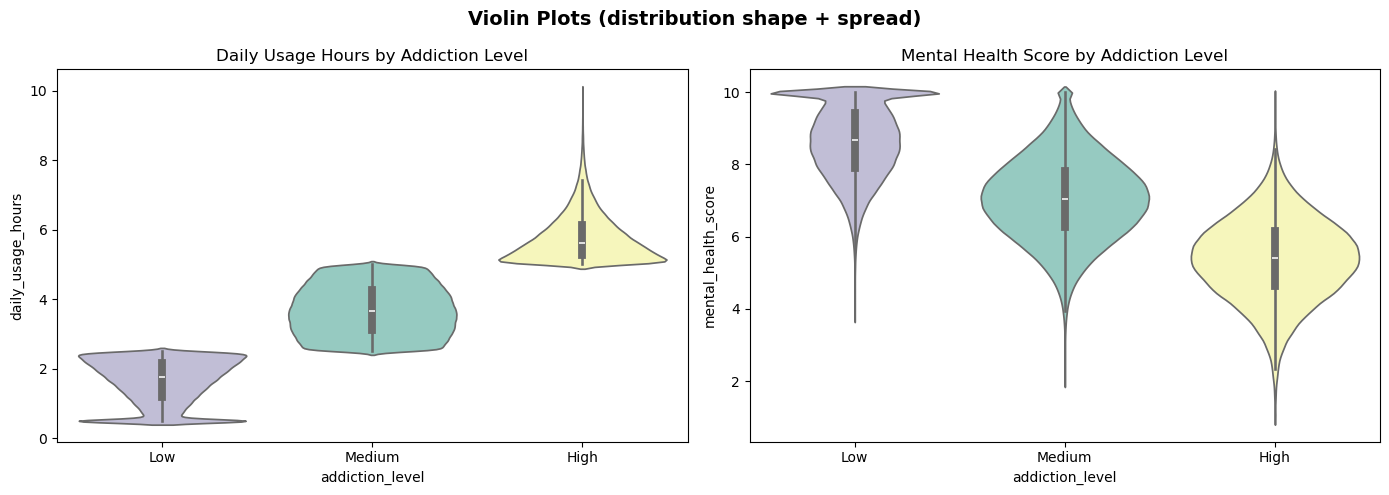

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Violin Plots (distribution shape + spread)',
             fontsize=14, fontweight='bold')
 
sns.violinplot(x=TARGET, y='daily_usage_hours', data=df,
               order=TARGET_ORDER, palette='Set3',
               hue=TARGET, legend=False,          # ← add these two
               ax=axes[0])
axes[0].set_title('Daily Usage Hours by Addiction Level')
sns.violinplot(x=TARGET, y='mental_health_score', data=df,
               order=TARGET_ORDER, palette='Set3',
               hue=TARGET, legend=False,          # ← add these two
               ax=axes[1])
axes[1].set_title('Mental Health Score by Addiction Level')
 
plt.tight_layout()
plt.show()

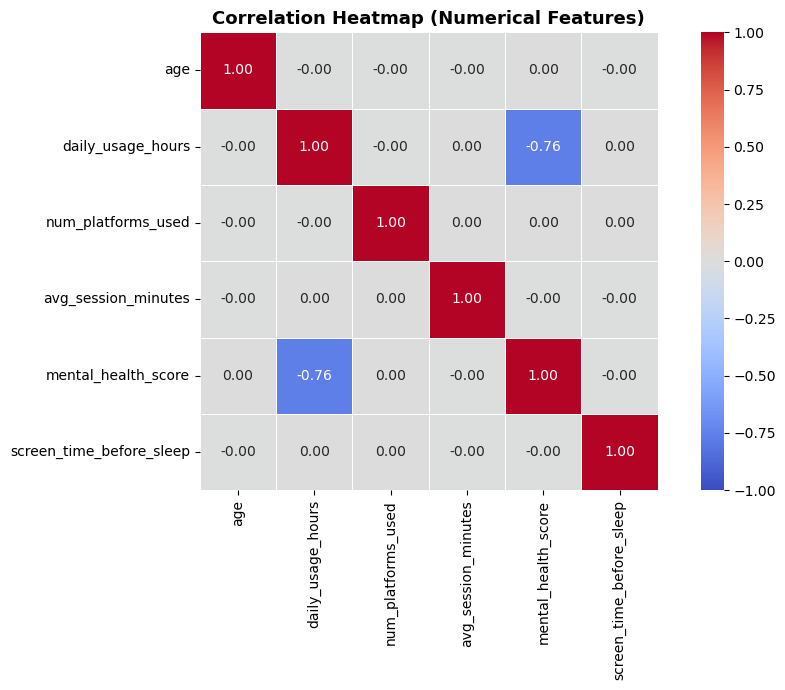

 Highly correlated pairs (|r| > 0.85):
  (These may cause multicollinearity — consider dropping one)
  None found — no multicollinearity issue.



In [19]:
# Correlation Heatmap 
plt.figure(figsize=(10, 7))
corr_matrix = df[NUM_COLS].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numerical Features)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Multicollinearity check — flag pairs with |r| > 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(c, r, upper.loc[r, c])
             for c in upper.columns
             for r in upper.index
             if pd.notna(upper.loc[r, c]) and abs(upper.loc[r, c]) > 0.85]

print(' Highly correlated pairs (|r| > 0.85):')
print('  (These may cause multicollinearity — consider dropping one)')

if high_corr:
    for pair in high_corr:
        print(f'  {pair[0]} ↔ {pair[1]}: {pair[2]:.3f}')
else:
    print('  None found — no multicollinearity issue.')
print()
 

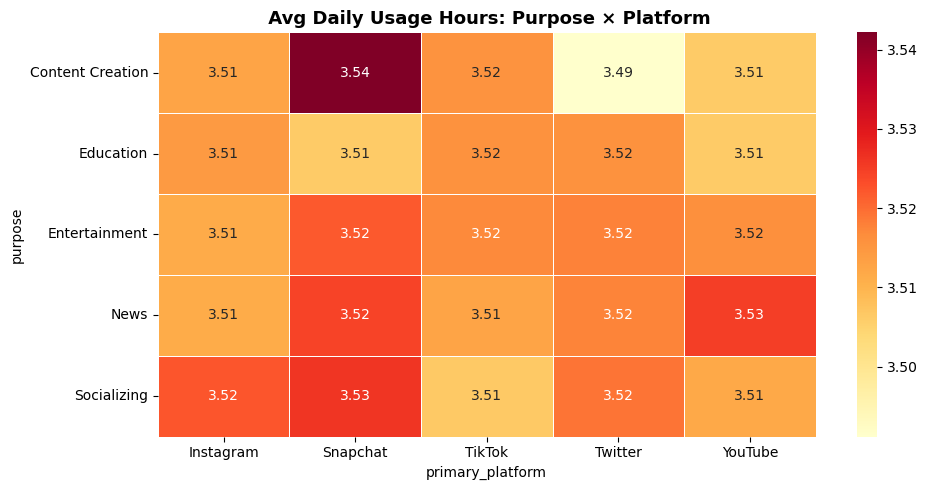

In [20]:
# Pivot Heatmap — Purpose × Platform → avg daily usage
pivot = df.groupby(['purpose', 'primary_platform'])['daily_usage_hours'].mean().unstack()
 
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title(' Avg Daily Usage Hours: Purpose × Platform',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

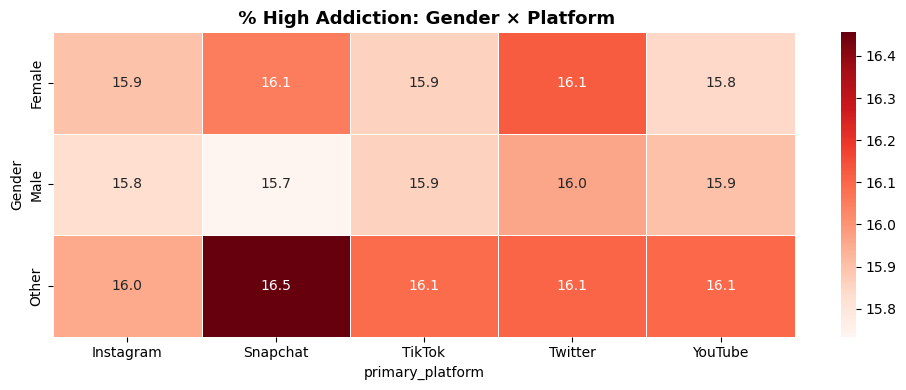

In [21]:
pivot2 = (df[df[TARGET] == 'High']
          .groupby(['gender', 'primary_platform'])
          .size()
          .div(df.groupby(['gender', 'primary_platform']).size())
          .mul(100)
          .unstack())
 
plt.figure(figsize=(10, 4))
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='Reds', linewidths=0.5)
plt.title(' % High Addiction: Gender × Platform',
          fontsize=13, fontweight='bold')
plt.ylabel('Gender')
plt.tight_layout()
plt.show()

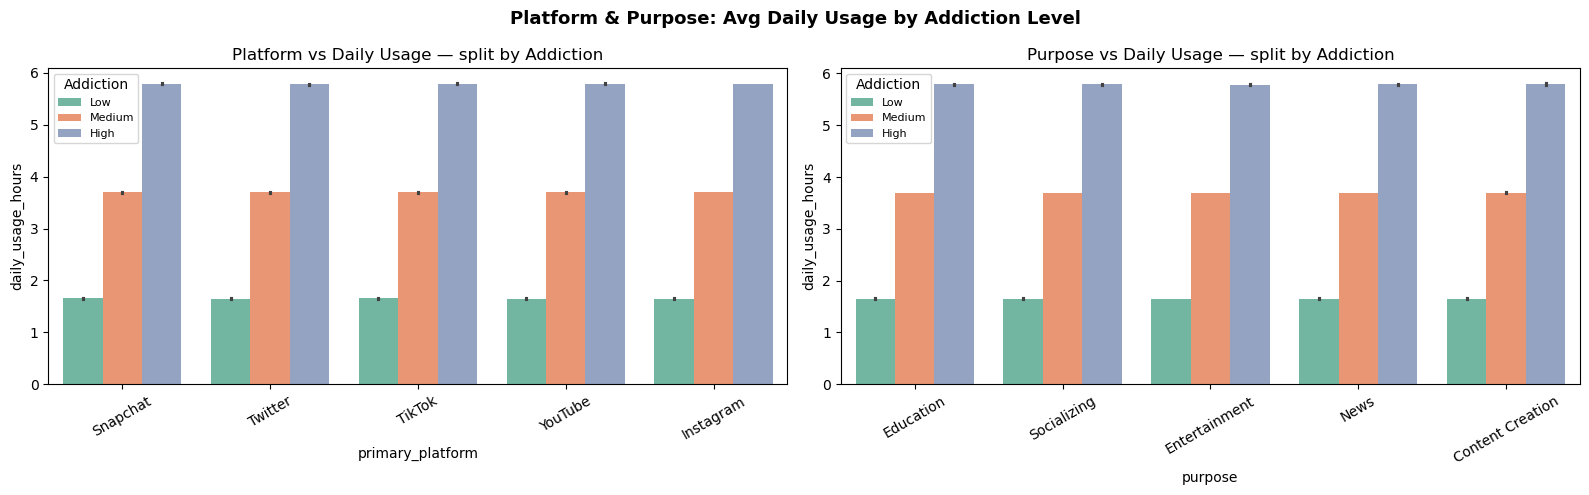

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Platform & Purpose: Avg Daily Usage by Addiction Level',
             fontsize=13, fontweight='bold')
 
sns.barplot(x='primary_platform', y='daily_usage_hours', hue=TARGET,
            hue_order=TARGET_ORDER, data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Platform vs Daily Usage — split by Addiction')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Addiction', fontsize=8)
 
sns.barplot(x='purpose', y='daily_usage_hours', hue=TARGET,
            hue_order=TARGET_ORDER, data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Purpose vs Daily Usage — split by Addiction')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Addiction', fontsize=8)
 
plt.tight_layout()
plt.show()

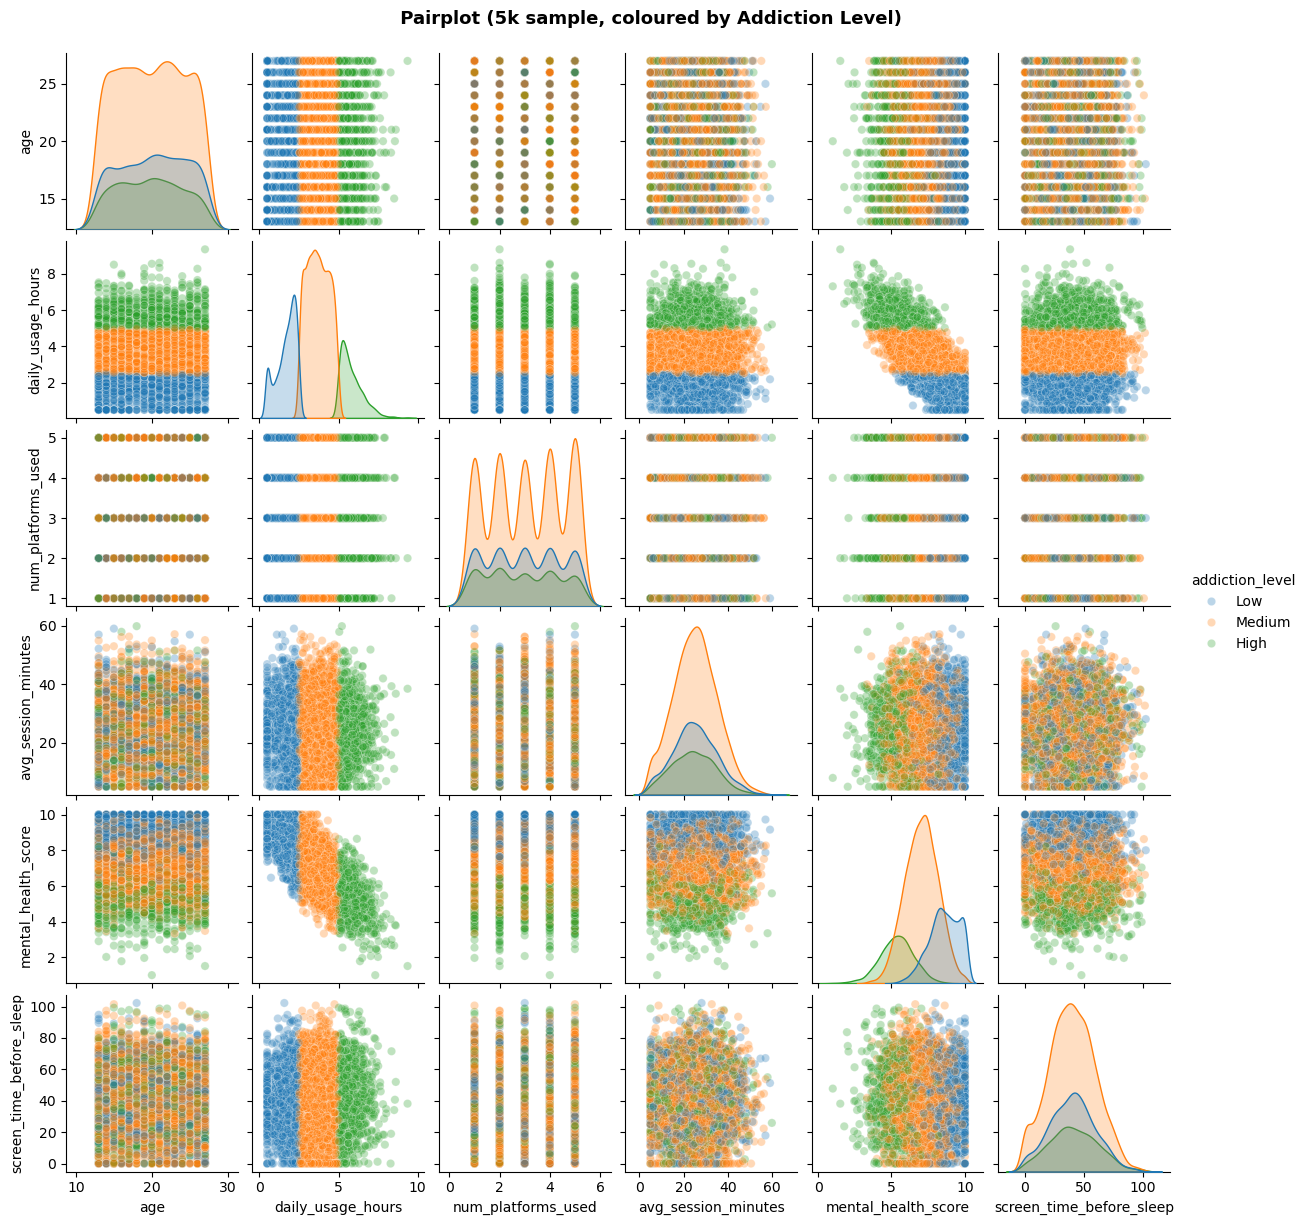

In [23]:
sns.pairplot(df_sample[NUM_COLS + [TARGET]],
             hue=TARGET,
             hue_order=TARGET_ORDER,
             diag_kind='kde',
             plot_kws={'alpha': 0.3},
             height=2)
plt.suptitle(' Pairplot (5k sample, coloured by Addiction Level)',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

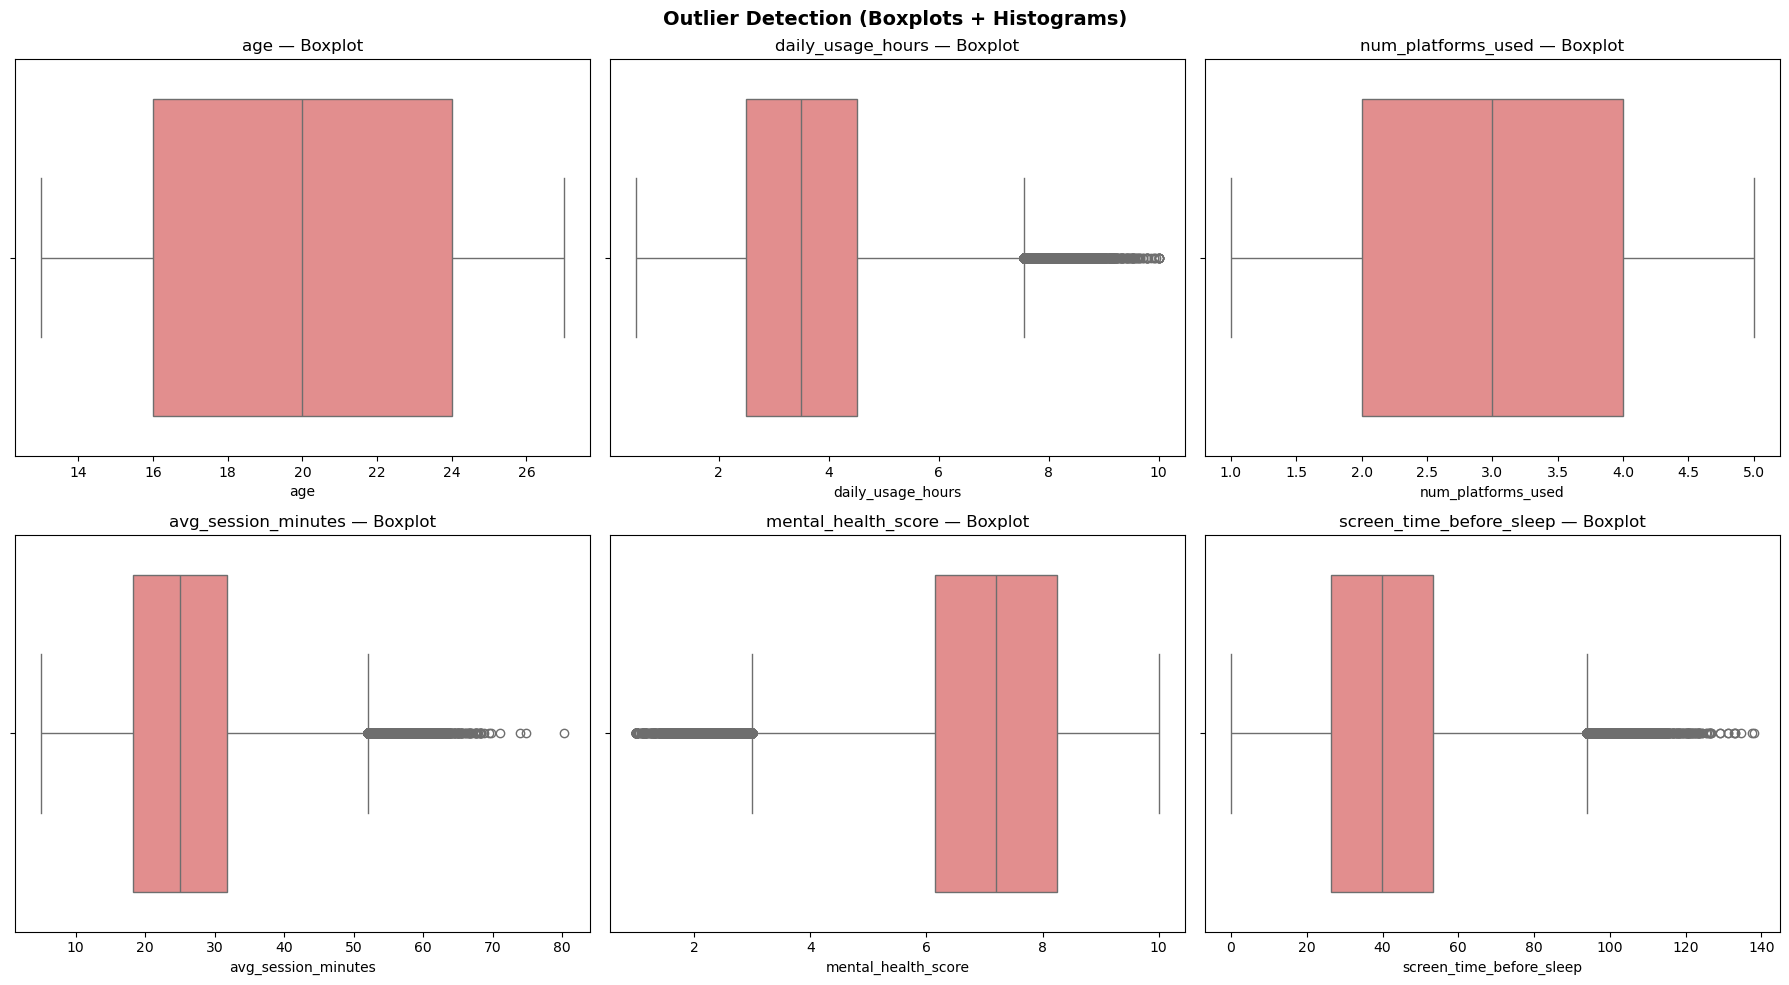

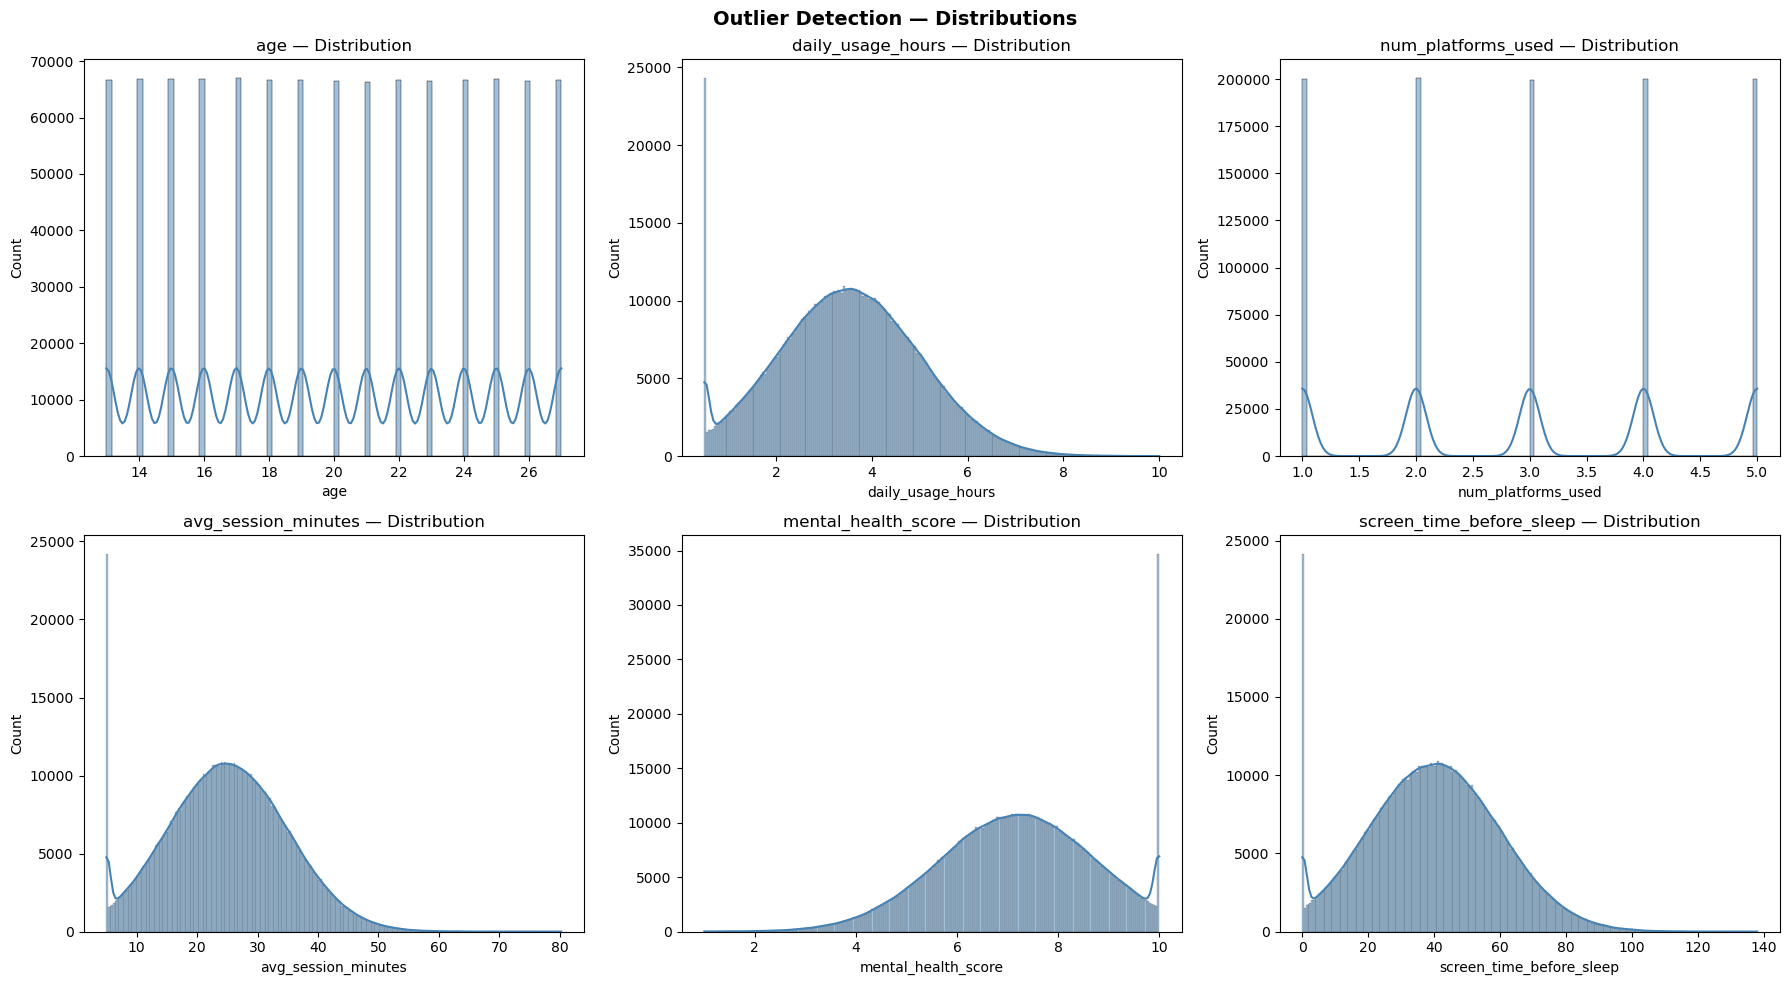

In [24]:
# Visual Detection
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Outlier Detection (Boxplots + Histograms)',
             fontsize=14, fontweight='bold')

# NUM_COLS has 6 items but axes[0] only has 3 columns
# Fix: split NUM_COLS into first 3 (row 0) and last 3 (row 1 histograms)
for i, col in enumerate(NUM_COLS[:3]):
    sns.boxplot(x=df[col], ax=axes[0, i], color='lightcoral')   # removed hue trick
    axes[0, i].set_title(f'{col} — Boxplot')

for i, col in enumerate(NUM_COLS[3:]):                           # last 3 cols
    sns.boxplot(x=df[col], ax=axes[1, i], color='lightcoral')
    axes[1, i].set_title(f'{col} — Boxplot')

plt.tight_layout()
plt.show()

# Separate figure for histograms
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Outlier Detection — Distributions', fontsize=14, fontweight='bold')

for i, col in enumerate(NUM_COLS[:3]):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'{col} — Distribution')

for i, col in enumerate(NUM_COLS[3:]):
    sns.histplot(df[col], kde=True, ax=axes[1, i], color='steelblue')
    axes[1, i].set_title(f'{col} — Distribution')

plt.tight_layout()
plt.show()


In [25]:
#  IQR Method — detect and cap all numeric columns 
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print(f'  {column}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)'
          f'  |  Bounds: [{lower:.2f}, {upper:.2f}]')
    return lower, upper


print('IQR Outlier Report')

bounds = {}
for col in NUM_COLS:
    bounds[col] = detect_outliers_iqr(df, col)

# Cap outliers (Winsorise) — safer than removing rows
# We cap instead of drop because 1M rows means we can afford to keep all data
for col in NUM_COLS:
    lower, upper = bounds[col]
    df[col] = df[col].clip(lower=lower, upper=upper)


IQR Outlier Report
  age: 0 outliers (0.0%)  |  Bounds: [4.00, 36.00]
  daily_usage_hours: 3545 outliers (0.4%)  |  Bounds: [-0.53, 7.54]
  num_platforms_used: 0 outliers (0.0%)  |  Bounds: [-1.00, 7.00]
  avg_session_minutes: 3446 outliers (0.3%)  |  Bounds: [-2.00, 52.01]
  mental_health_score: 3595 outliers (0.4%)  |  Bounds: [3.00, 11.39]
  screen_time_before_sleep: 3488 outliers (0.3%)  |  Bounds: [-13.99, 93.87]


In [26]:
# ENCODING CATEGORICAL VARIABLES
#  Label Encode the TARGET (ordinal — has meaningful order)
addiction_order = {'Low': 0, 'Medium': 1, 'High': 2}
df['addiction_level_enc'] = df['addiction_level'].map(addiction_order)

print('Target Encoding (addiction_level)')
print(df[['addiction_level', 'addiction_level_enc']].value_counts().sort_index())


#  One-Hot Encode nominal features 
# drop_first=True avoids the Dummy Variable Trap
nominal_cols = ['gender', 'country', 'primary_platform', 'purpose']

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Drop the original string target (keep the encoded version)
df_encoded.drop(columns=['addiction_level'], inplace=True)

print('\nAfter One-Hot Encoding:')
print(f'  Shape before: {df.shape}')
print(f'  Shape after:  {df_encoded.shape}')
print(f'  New columns:  {list(df_encoded.columns)}')

Target Encoding (addiction_level)
addiction_level  addiction_level_enc
High             2                      158937
Low              0                      251220
Medium           1                      589843
Name: count, dtype: int64

After One-Hot Encoding:
  Shape before: (1000000, 13)
  Shape after:  (1000000, 24)
  New columns:  ['age', 'daily_usage_hours', 'num_platforms_used', 'avg_session_minutes', 'night_usage', 'mental_health_score', 'screen_time_before_sleep', 'addiction_level_enc', 'gender_Male', 'gender_Other', 'country_Brazil', 'country_Canada', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'primary_platform_Snapchat', 'primary_platform_TikTok', 'primary_platform_Twitter', 'primary_platform_YouTube', 'purpose_Education', 'purpose_Entertainment', 'purpose_News', 'purpose_Socializing']


In [27]:
# TRAIN/TEST SPLIT → THEN FEATURE SCALING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Split BEFORE scaling — critical to avoid data leakage
X = df_encoded.drop(columns=['addiction_level_enc'])
y = df_encoded['addiction_level_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    # stratify=y → keeps Low/Medium/High proportions equal in both splits
)
print(' Train/Test Split')
print(f'  X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'  y_train distribution:\n{y_train.value_counts(normalize=True).round(3)}')

# Scale numeric columns only — OHE columns (0/1) don't need scaling
# RobustScaler chosen because we have outliers (even after capping, tails exist)
scaler = RobustScaler()

X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])  # fit + transform
X_test[NUM_COLS]  = scaler.transform(X_test[NUM_COLS])       # transform ONLY

print('\n Scaling complete (RobustScaler — fit on train only)')
print(f'  Sample scaled values (X_train first row):\n'
      f'{X_train[NUM_COLS].iloc[0].round(3)}')

 Train/Test Split
  X_train: (800000, 23)  |  X_test: (200000, 23)
  y_train distribution:
addiction_level_enc
1    0.590
0    0.251
2    0.159
Name: proportion, dtype: float64

 Scaling complete (RobustScaler — fit on train only)
  Sample scaled values (X_train first row):
age                         0.375
daily_usage_hours          -0.814
num_platforms_used         -1.000
avg_session_minutes        -0.671
mental_health_score         0.329
screen_time_before_sleep    1.017
Name: 840114, dtype: float64


Skewness Check
screen_time_before_sleep    0.099
avg_session_minutes         0.097
daily_usage_hours           0.096
age                         0.002
num_platforms_used          0.001
mental_health_score        -0.165
dtype: float64

  Rule: |skew| > 0.5 → transformation needed


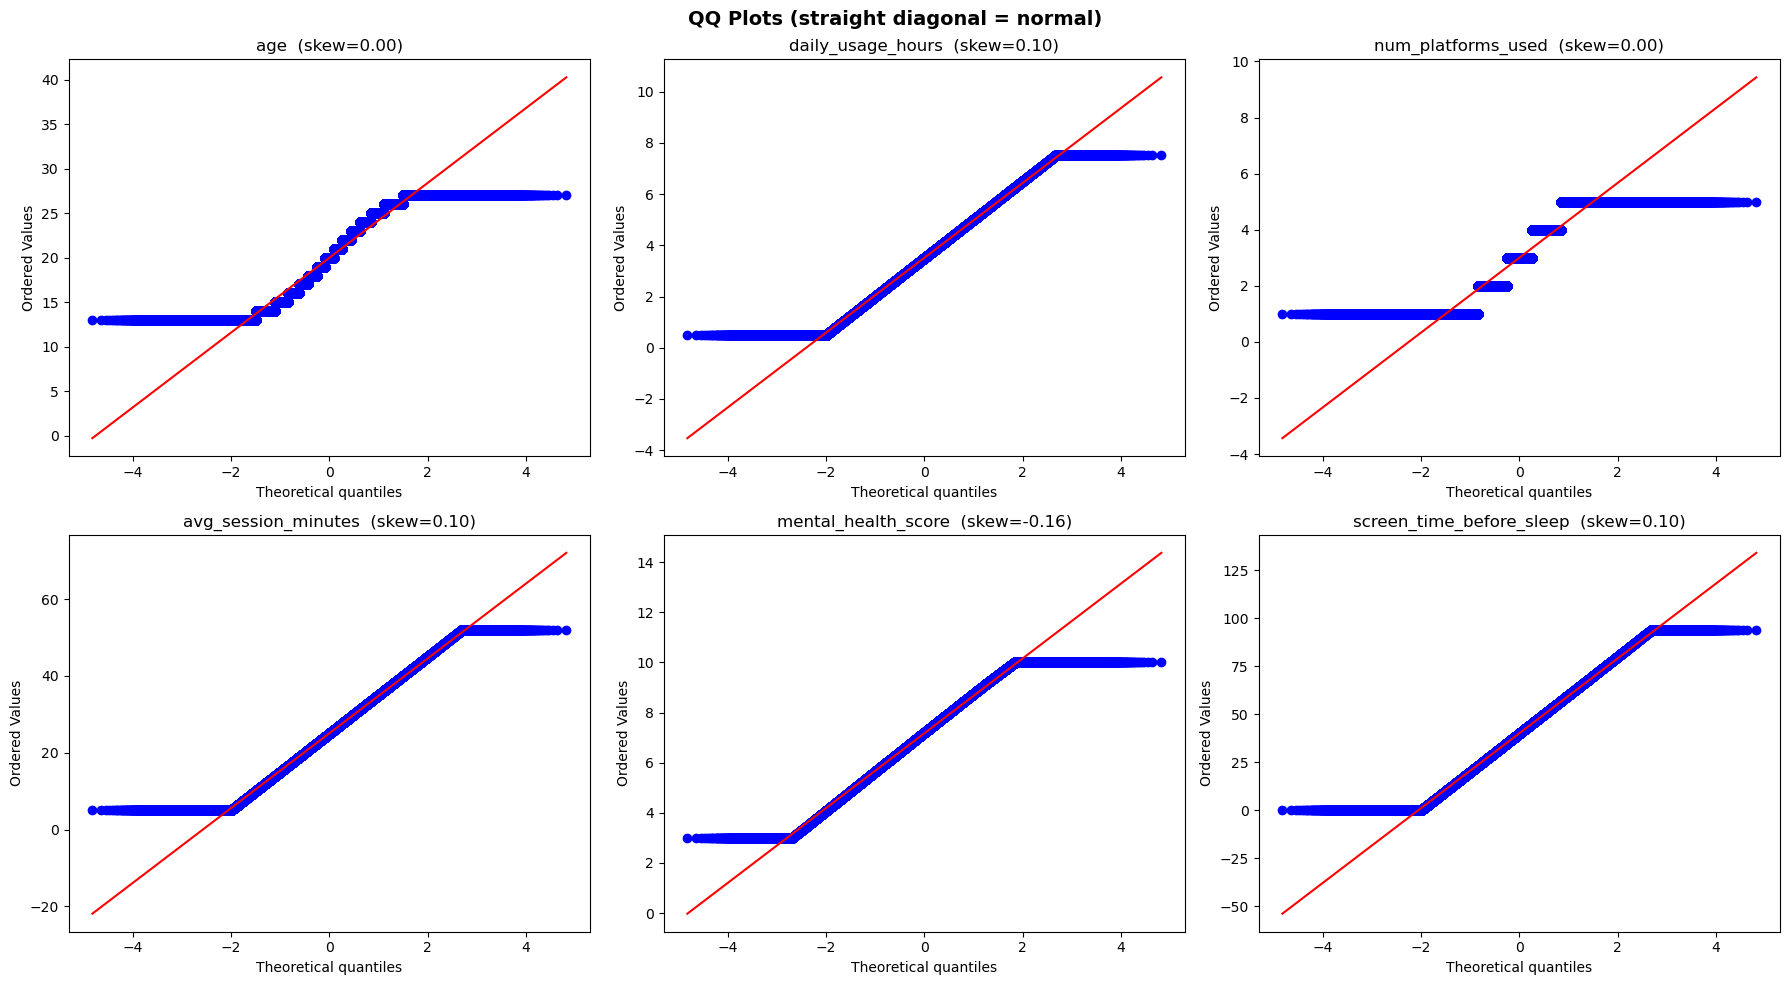


No transformation needed — all skewness values < 0.5


In [28]:
# SKEWNESS CHECK & GAUSSIAN TRANSFORMATION
# Note: run on df (raw data) — skewness should be checked before scaling

print('Skewness Check')
skewness = df[NUM_COLS].skew().sort_values(ascending=False)
print(skewness.round(3))
print('\n  Rule: |skew| > 0.5 → transformation needed')

# Visualise skewness — QQ plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('QQ Plots (straight diagonal = normal)',
             fontsize=14, fontweight='bold')
for ax, col in zip(axes.flatten(), NUM_COLS):
    stats.probplot(df[col], dist='norm', plot=ax)
    ax.set_title(f'{col}  (skew={df[col].skew():.2f})')
plt.tight_layout()
plt.show()

# Check if any column needs transformation
skewed_cols = skewness[skewness.abs() > 0.5].index.tolist()
if skewed_cols:
    print(f'\nColumns to transform: {skewed_cols}')
else:
    print('\nNo transformation needed — all skewness values < 0.5')


In [29]:
from sklearn.ensemble import RandomForestClassifier

# Correlation with target 
# Convert X_train back to DataFrame with column names for readability
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)

# Correlation of each feature with target
corr_with_target = X_train_df.corrwith(pd.Series(y_train.values)).abs()
corr_with_target = corr_with_target.sort_values(ascending=False)

print('Feature Correlation with Target')

print(corr_with_target.round(3))

Feature Correlation with Target
primary_platform_Snapchat    0.004
purpose_Socializing          0.002
screen_time_before_sleep     0.002
purpose_Entertainment        0.002
primary_platform_YouTube     0.002
num_platforms_used           0.002
country_UK                   0.002
night_usage                  0.001
primary_platform_TikTok      0.001
country_USA                  0.001
purpose_News                 0.001
gender_Male                  0.001
country_Canada               0.001
age                          0.001
avg_session_minutes          0.000
daily_usage_hours            0.000
country_Brazil               0.000
purpose_Education            0.000
primary_platform_Twitter     0.000
country_Germany              0.000
gender_Other                 0.000
country_India                0.000
mental_health_score          0.000
dtype: float64



Feature Importances (Random Forest)
                      Feature  Importance
0           daily_usage_hours    0.832143
1         mental_health_score    0.166378
2         avg_session_minutes    0.000386
3    screen_time_before_sleep    0.000386
4                         age    0.000162
5          num_platforms_used    0.000096
6                 night_usage    0.000040
7                 gender_Male    0.000038
8                gender_Other    0.000031
9       purpose_Entertainment    0.000029
10   primary_platform_YouTube    0.000028
11          purpose_Education    0.000028
12        purpose_Socializing    0.000027
13  primary_platform_Snapchat    0.000026
14    primary_platform_TikTok    0.000026
15   primary_platform_Twitter    0.000026
16               purpose_News    0.000024
17              country_India    0.000024
18                 country_UK    0.000022
19             country_Brazil    0.000022
20                country_USA    0.000020
21            country_Germany    0.0000

C:\Users\vyoma\AppData\Local\Temp\ipykernel_27516\1776333962.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


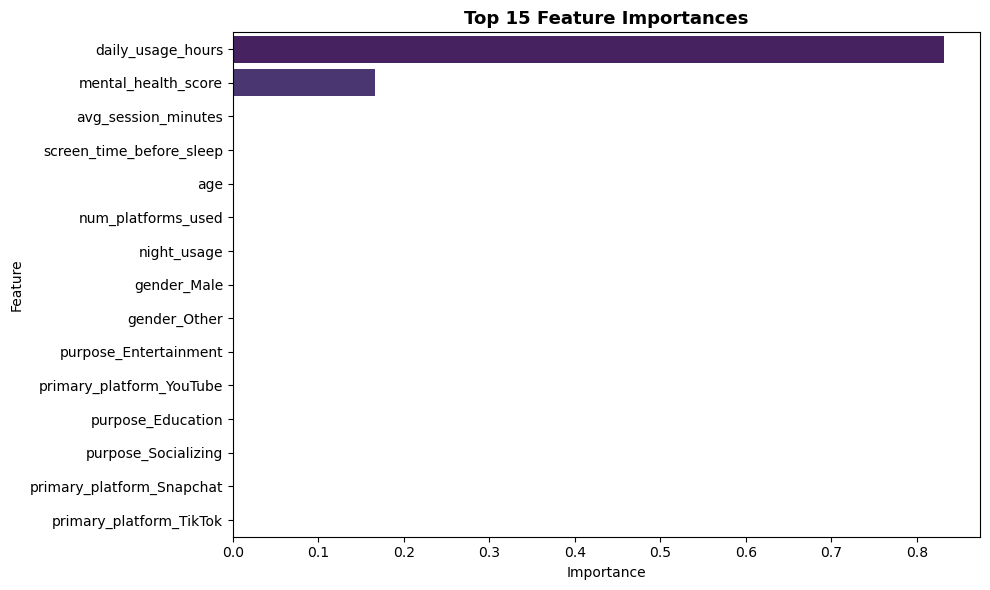


Weak features to drop (importance < 1%): ['avg_session_minutes', 'screen_time_before_sleep', 'age', 'num_platforms_used', 'night_usage', 'gender_Male', 'gender_Other', 'purpose_Entertainment', 'primary_platform_YouTube', 'purpose_Education', 'purpose_Socializing', 'primary_platform_Snapchat', 'primary_platform_TikTok', 'primary_platform_Twitter', 'purpose_News', 'country_India', 'country_UK', 'country_Brazil', 'country_USA', 'country_Germany', 'country_Canada']
  X_train after selection: (800000, 2)
  X_test  after selection: (200000, 2)


In [30]:
rf_selector = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,          # limit depth — speeds up this selection step
    random_state=42,
    n_jobs=-1              # use all CPU cores
)
rf_selector.fit(X_train_df, y_train)

importance_df = pd.DataFrame({
    'Feature'   : X_train_df.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('\nFeature Importances (Random Forest)')
print(importance_df.to_string())
# Visualise top features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature',
            data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Drop features with near-zero importance (< 1%)
weak_features = importance_df[importance_df['Importance'] < 0.01]['Feature'].tolist()
print(f'\nWeak features to drop (importance < 1%): {weak_features}')

X_train_df.drop(columns=weak_features, inplace=True)
X_test_df.drop(columns=weak_features,  inplace=True)

print(f'  X_train after selection: {X_train_df.shape}')
print(f'  X_test  after selection: {X_test_df.shape}')

Training: Logistic Regression
  Time: 5.9s

  Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00     50244
      Medium       1.00      1.00      1.00    117969
        High       1.00      1.00      1.00     31787

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000

Training: Random Forest
  Time: 26.3s

  Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00     50244
      Medium       1.00      1.00      1.00    117969
        High       1.00      1.00      1.00     31787

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



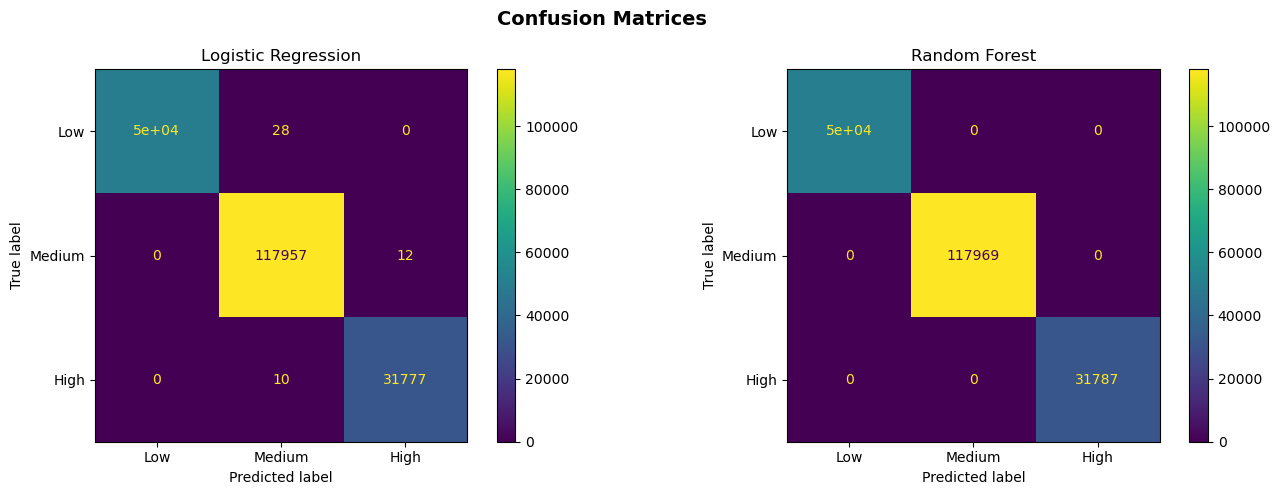

In [31]:
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (classification_report,
                                     confusion_matrix,
                                     ConfusionMatrixDisplay)
import time

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
}

results = {}

for name, model in models.items():
    
    print(f'Training: {name}')
    start = time.time()

    model.fit(X_train_df, y_train)
    y_pred = model.predict(X_test_df)

    elapsed = time.time() - start
    print(f'  Time: {elapsed:.1f}s')
    print(f'\n  Classification Report:')
    print(classification_report(
        y_test, y_pred,
        target_names=['Low', 'Medium', 'High']
    ))

    results[name] = {
        'model' : model,
        'y_pred': y_pred,
    }


# ── Confusion Matrices side by side ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Low', 'Medium', 'High']).plot(ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()


In [32]:
from sklearn.metrics import accuracy_score, f1_score


print('MODEL COMPARISON SUMMARY')

print(f'  {"Model":<25} {"Accuracy":>10} {"F1 (macro)":>12}')

for name, res in results.items():
    acc = accuracy_score(y_test, res['y_pred'])
    f1  = f1_score(y_test, res['y_pred'], average='macro')
    print(f'  {name:<25} {acc:>10.3f} {f1:>12.3f}')

MODEL COMPARISON SUMMARY
  Model                       Accuracy   F1 (macro)
  Logistic Regression            1.000        1.000
  Random Forest                  1.000        1.000


              precision    recall  f1-score   support

         Low       1.00      1.00      1.00     50244
      Medium       1.00      1.00      1.00    117969
        High       1.00      1.00      1.00     31787

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000

CV F1 macro: 0.999 ± 0.000


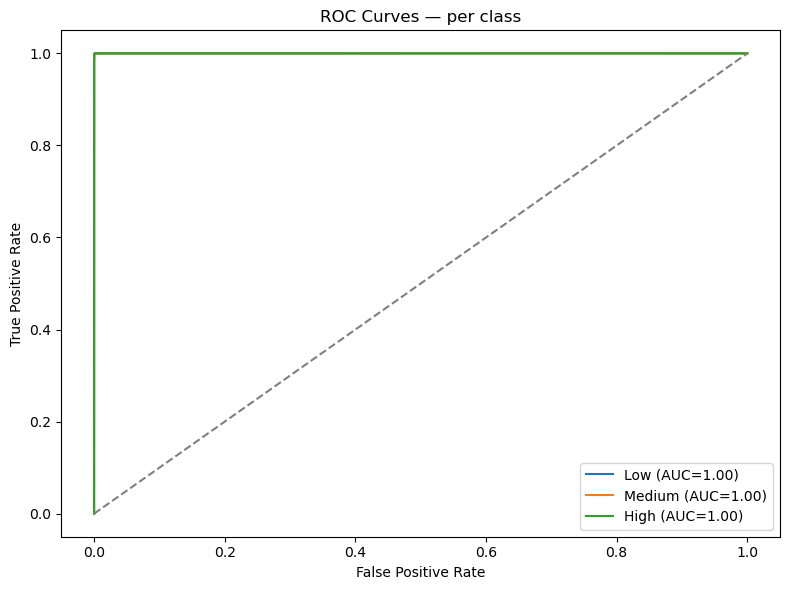

Model saved.


In [33]:
!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, max_depth=6,
                    learning_rate=0.1, random_state=42,
                    eval_metric='mlogloss', n_jobs=-1)
xgb.fit(X_train_df, y_train)
y_pred_xgb = xgb.predict(X_test_df)
print(classification_report(y_test, y_pred_xgb,
      target_names=['Low', 'Medium', 'High']))

# Cross-validation on best model
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(xgb, X_train_df, y_train,
                             cv=5, scoring='f1_macro', n_jobs=-1)
print(f'CV F1 macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

#  ROC / AUC curves (one curve per class)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_prob = xgb.predict_proba(X_test_df)

fig, ax = plt.subplots(figsize=(8, 6))
for i, label in enumerate(['Low', 'Medium', 'High']):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc(fpr,tpr):.2f})')
ax.plot([0,1],[0,1],'--', color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — per class')
ax.legend()
plt.tight_layout()
plt.show()

# Save the best model
import joblib
joblib.dump(xgb, 'addiction_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Model saved.')